# Homework 2

## Group Number: 112
  
### Group Members:
- Duarte Rebelo de São José: ist1103708
- Tiago Ramos da Rocha Neves Caixinha: ist1102437

# Imports and data loading

In [26]:
from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.metrics import confusion_matrix
import seaborn as sns

data = arff.loadarff('../column_diagnosis.arff')
df = pd.DataFrame(data[0])
df['class'] = df['class'].str.decode('utf-8')

X = df.drop(columns=['class'])
y = df['class']

# Problem 1

### Generating boxplots

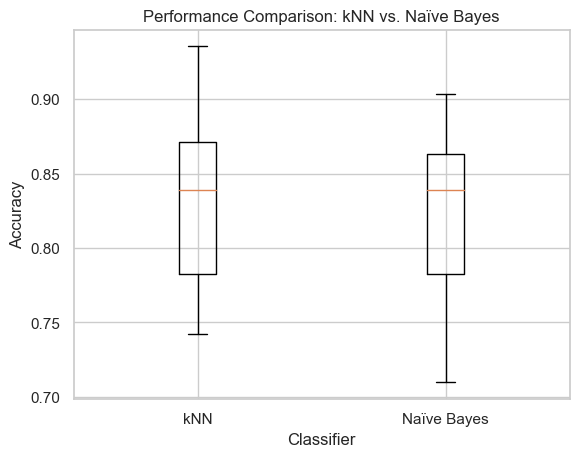

In [30]:
knn_classifier = KNeighborsClassifier(n_neighbors=5)
nb_classifier = GaussianNB()

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)

knn_scores = []
nb_scores = []

for train_index, test_index in skf.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    knn_classifier.fit(X_train, y_train)
    knn_score = knn_classifier.score(X_test, y_test)
    knn_scores.append(knn_score)

    nb_classifier.fit(X_train, y_train)
    nb_score = nb_classifier.score(X_test, y_test)
    nb_scores.append(nb_score)

plt.boxplot([knn_scores, nb_scores], labels=["kNN", "Naïve Bayes"])
plt.ylabel("Accuracy")
plt.xlabel("Classifier")
plt.title("Performance Comparison: kNN vs. Naïve Bayes")
plt.show()

### Testing the given hypothesis

In [28]:
t_stat, p_value = stats.ttest_rel(knn_scores, nb_scores)

alpha = 0.05

if p_value < alpha:
    print("The given hypothesis should be rejected.")
else:
    print("The given hypothesis should be accepted.")

The given hypothesis should be accepted.


# Problem 2

### Training the decison tree with various depth limits

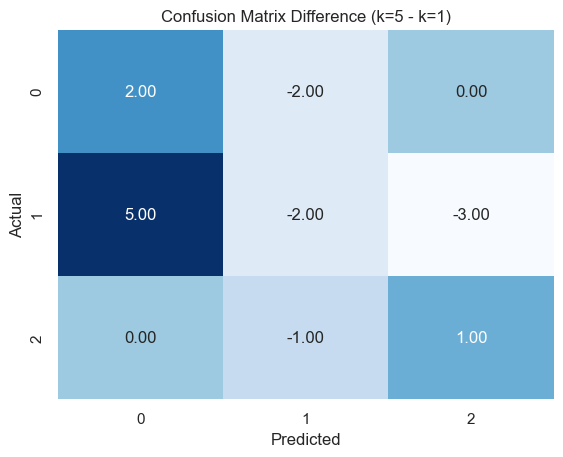

In [29]:
unique_classes = np.unique(y)

knn_1 = KNeighborsClassifier(n_neighbors=1)
knn_5 = KNeighborsClassifier(n_neighbors=5)

num_classes = len(unique_classes)
cumulative_cm_1 = np.zeros((num_classes, num_classes))
cumulative_cm_5 = np.zeros((num_classes, num_classes))

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)

for train_index, test_index in skf.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    knn_1.fit(X_train, y_train)
    y_pred_1 = knn_1.predict(X_test)
    cm_1 = confusion_matrix(y_test, y_pred_1, labels=unique_classes)
    cumulative_cm_1 += cm_1

    knn_5.fit(X_train, y_train)
    y_pred_5 = knn_5.predict(X_test)
    cm_5 = confusion_matrix(y_test, y_pred_5, labels=unique_classes)
    cumulative_cm_5 += cm_5

cm_diff = cumulative_cm_5 - cumulative_cm_1

sns.heatmap(cm_diff_float, annot=True, fmt='.2f', cmap='Blues', cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Difference (k=5 - k=1)")
plt.show()

### Comment

The heatmap shows the differences in confusion matrices between kNN with k=5 and k=1.

# Problem 3

### Identifying three possible difficulties of Naïve Bayes

Naïve Bayes is a simple and effective classifier, but it may face difficulties in certain scenarios:

1. **Assumption of Independence:** Naïve Bayes assumes that features are conditionally independent given the class label. In real-world datasets, this assumption may not hold true, leading to suboptimal performance when features are correlated.

2. **Continuous Features:** Naïve Bayes with Gaussian assumption assumes that continuous features follow a Gaussian distribution. If the data does not meet this assumption, the model may not capture the underlying distribution accurately.

3. **Data Imbalance:** Naïve Bayes can be sensitive to class imbalances. If one class has significantly more instances than the others, the model may be biased towards the majority class and perform poorly on minority classes.